In [1]:
import pandas as pd
import geopandas as gpd



In [ ]:
file = r"C:\Users\arber\Desktop\georeferencer\georeferencer\data\bplan.gpkg"
bplan = gpd.read_file(file, layer="PlaeneNachBauGB")
pd.set_option('display.max_columns', None)
bplan.head()

DataSourceError: C:\Users\arber\Desktop\georeferencer\georeferencer\data: Permission denied

In [8]:

print(bplan["scanurl"].iloc[40])
print(bplan.iloc[40].geometry)

https://www.menden.de/fileadmin/user_upload/Leben_in_Menden/Stadtplanung/Bebauungsplaene/BP_199_Habichtstrasse.pdf
POLYGON ((419935.8340999996 5696869.866, 419911.2237999998 5696865.707800001, 419891.6015999997 5696862.3893, 419874.4286000002 5696883.461100001, 419868.26109999977 5696891.0282000005, 419837.29360000044 5696929.043500001, 419829.51680000033 5696938.5798, 419805.0267000003 5696968.6281, 419818.7812999999 5696974.605699999, 419827.9676999999 5696979.1537999995, 419823.30960000027 5696988.0604, 419795.5208999999 5697023.386700001, 419808.6058 5697037.221100001, 419799.47109999973 5697045.8454, 419815.51300000027 5697065.9350000005, 419809.9455000004 5697072.5472, 419799.97950000037 5697081.024, 419806.2670999998 5697088.890799999, 419784.87569999974 5697105.714400001, 419778.3683000002 5697110.8224, 419761.3351999996 5697124.177300001, 419761.7549999999 5697124.7171, 419756.0872999998 5697130.604800001, 419751.1492999997 5697137.0023, 419750.0398000004 5697138.931600001, 41

In [ ]:
# Georeferenzierung des Bebauungsplans mit Affiner Transformation

## Workflow:
1. PDF → PNG konvertieren
2. Ziel-Polygon aus GeoDataFrame extrahieren
3. Passpunkte (Control Points) definieren
4. Affine Transformation anwenden
5. Als GeoTIFF speichern

In [23]:
# Imports für Georeferenzierung
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image
import fitz  # PyMuPDF
from pathlib import Path
import cv2  # OpenCV für automatische Feature-Erkennung

## Schritt 1: Ziel-Polygon extrahieren und visualisieren

CRS: EPSG:25832
Geometry Type: Polygon
Bounds: (419749.4000000004, 5696862.3893, 420028.74739999976, 5697178.685699999)


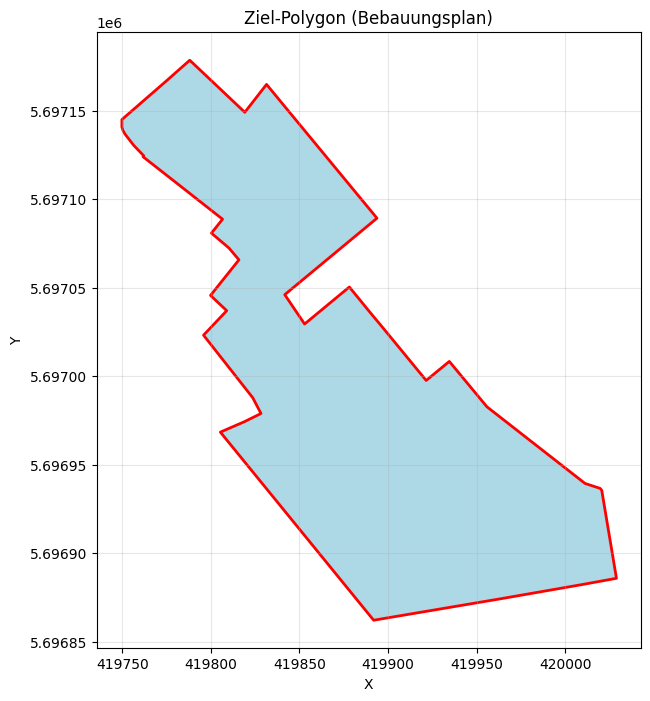

In [12]:
# Polygon extrahieren
target_polygon = bplan.iloc[40]
target_geom = target_polygon.geometry
target_crs = bplan.crs

print(f"CRS: {target_crs}")
print(f"Geometry Type: {target_geom.geom_type}")
print(f"Bounds: {target_geom.bounds}")

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 8))
bplan.iloc[40:41].plot(ax=ax, facecolor='lightblue', edgecolor='red', linewidth=2)
ax.set_title("Ziel-Polygon (Bebauungsplan)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.grid(True, alpha=0.3)
plt.show()

## Schritt 2: PDF → PNG konvertieren

In [6]:
def pdf_to_png(pdf_path, output_png, dpi=300):
    """
    Konvertiert PDF zu PNG mit PyMuPDF
    
    Args:
        pdf_path: Pfad zur PDF-Datei
        output_png: Ausgabe-PNG-Pfad
        dpi: Auflösung (Standard: 300)
    
    Returns:
        numpy array des Bildes (H, W, C)
    """
    pdf_document = fitz.open(pdf_path)
    page = pdf_document[0]  # Erste Seite
    
    # Zoom-Faktor für DPI
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)
    
    # Rendern als Pixmap
    pix = page.get_pixmap(matrix=mat)
    
    # Als PNG speichern
    pix.save(output_png)
    
    # Als numpy array laden
    img = Image.open(output_png)
    img_array = np.array(img)
    
    pdf_document.close()
    
    print(f"✓ PDF konvertiert: {output_png}")
    print(f"  Bildgröße: {img_array.shape}")
    
    return img_array

# PDF konvertieren
pdf_path = r"C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\BP_199_Habichtstrasse.pdf"
png_path = r"C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_temp.png"

img_array = pdf_to_png(pdf_path, png_path)

c:\Users\arber\Desktop\scouting-python\.venv\Lib\site-packages\PIL\Image.py:3442: DecompressionBombWarning: Image size (129460749 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


c:\Users\arber\Desktop\scouting-python\.venv\Lib\site-packages\PIL\Image.py:3442: DecompressionBombWarning: Image size (129460749 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


✓ PDF konvertiert: C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_temp.png
  Bildgröße: (9449, 13701, 3)


## Schritt 3: Passpunkte automatisch finden

**Automatische Strategie:**
1. Farbiges Polygon im PDF durch Color-Segmentierung finden
2. Konturen extrahieren und Ecken/Punkte identifizieren
3. Mit GeoDataFrame-Polygon matchen
4. Passpunkte generieren

### ℹ️ Wie funktioniert die Automatisierung?

Die automatische Passpunkt-Erkennung läuft in 3 Schritten:

1. **Farbsegmentierung** (HSV-basiert)
   - Testet verschiedene Farbbereiche (Rot, Orange, Gelb, Grün, Blau, Lila)
   - Findet farbig markierte Bereiche im PDF
   - Extrahiert die größte Kontur

2. **Kontur-Approximation** (Douglas-Peucker)
   - Vereinfacht die Kontur zu Eckpunkten
   - Liefert Pixel-Koordinaten der Polygon-Ecken

3. **Shape Matching**
   - Sortiert Punkte nach Winkel vom Zentroid
   - Ordnet Pixel-Punkte den Geo-Koordinaten zu
   - Berücksichtigt räumliche Anordnung

**Fallback:** Wenn keine Features erkannt werden → Bounding-Box-Transformation

Suche farbiges Polygon im PDF-Bild...
✓ Rosa/Pink + Gelb Plangebiet gefunden:
  Fläche: 19089248 Pixel²
  Anzahl Konturen: 4
  Vollständige Randpunkte: 23512
  → Resampled auf 500 Punkte


Suche farbiges Polygon im PDF-Bild...
✓ Rosa/Pink + Gelb Plangebiet gefunden:
  Fläche: 19089248 Pixel²
  Anzahl Konturen: 4
  Vollständige Randpunkte: 23512
  → Resampled auf 500 Punkte


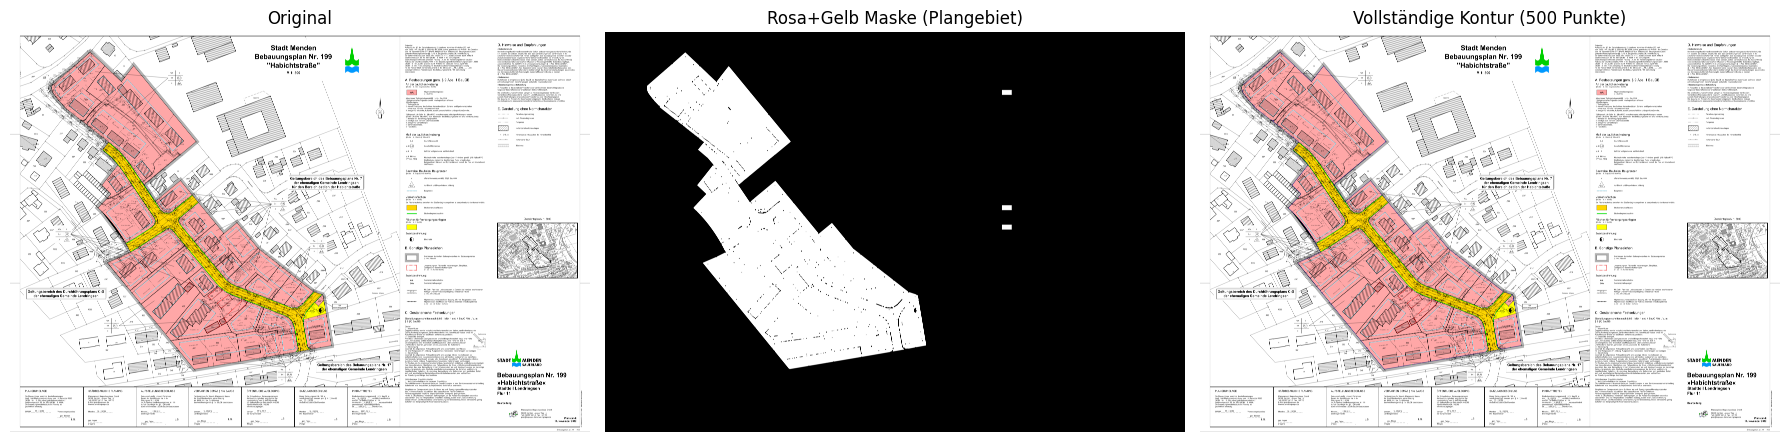

In [7]:
import cv2
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

def detect_colored_polygon(img_array, color_range=None, max_points=500, debug=False):
    """
    Findet die VOLLSTÄNDIGE äußere Kontur des Plangebiets (rosa + gelb).
    Keine Vereinfachung - gibt alle Randpunkte zurück.
    
    Args:
        img_array: RGB Bild als numpy array
        color_range: Tuple (lower_hsv, upper_hsv) für custom Farben
        max_points: Optional - resample auf diese Anzahl falls zu viele Punkte
        debug: Zeigt Debug-Visualisierungen
    
    Returns:
        Vollständige Randpunkte als numpy.ndarray (N x 2)
    """
    # BGR für OpenCV
    if img_array.shape[2] == 4:  # RGBA
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGBA2BGR)
    else:  # RGB
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    
    # HSV für Farbsegmentierung
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # Rosa/Pink UND Gelb zusammen (Plangebiet)
    if color_range is None:
        color_ranges = [
            # Pink/Magenta (helleres Rosa)
            ((140, 30, 80), (170, 255, 255)),
            # Rot/Rosa (dunkleres Rosa, am Rand zu Rot)
            ((0, 30, 80), (10, 255, 255)),
            ((170, 30, 80), (180, 255, 255)),
            # GELB (Straße innen)
            ((20, 100, 100), (30, 255, 255)),
        ]
    else:
        color_ranges = [color_range]
    
    all_masks = []
    for lower, upper in color_ranges:
        mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
        all_masks.append(mask)
    
    # Masken kombinieren (rosa + gelb = Plangebiet)
    combined_mask = np.zeros_like(all_masks[0])
    for mask in all_masks:
        combined_mask = cv2.bitwise_or(combined_mask, mask)
    
    # Morphologische Operationen - größerer Kernel um Löcher zu schließen
    kernel = np.ones((15, 15), np.uint8)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)
    
    # Konturen finden - CHAIN_APPROX_NONE für vollständige Punkte
    contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    if len(contours) == 0:
        print("⚠️  Kein rosa/gelb Plangebiet gefunden!")
        return None
    
    # Größte Kontur wählen
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    
    print(f"✓ Rosa/Pink + Gelb Plangebiet gefunden:")
    print(f"  Fläche: {area:.0f} Pixel²")
    print(f"  Anzahl Konturen: {len(contours)}")
    
    # Vollständige Randpunkte extrahieren (KEINE Vereinfachung!)
    contour_points = largest_contour.reshape(-1, 2)
    
    print(f"  Vollständige Randpunkte: {len(contour_points)}")
    
    # Optional: Resample falls zu viele Punkte
    if max_points is not None and len(contour_points) > max_points:
        # Gleichmäßig entlang der Kontur samplen
        indices = np.linspace(0, len(contour_points) - 1, max_points, dtype=int)
        contour_points = contour_points[indices]
        print(f"  → Resampled auf {len(contour_points)} Punkte")
    
    # Debug-Visualisierung
    if debug:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        axes[0].axis('off')
        
        axes[1].imshow(combined_mask, cmap='gray')
        axes[1].set_title("Rosa+Gelb Maske (Plangebiet)")
        axes[1].axis('off')
        
        result = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
        # Zeichne vollständige Kontur in Blau
        cv2.drawContours(result, [largest_contour], -1, (0, 0, 255), 2)
        # Zeichne Sampling-Punkte in Grün
        for pt in contour_points[::max(1, len(contour_points)//50)]:  # Zeige bis zu 50 Punkte
            cv2.circle(result, tuple(pt), 5, (0, 255, 0), -1)
        axes[2].imshow(result)
        axes[2].set_title(f"Vollständige Kontur ({len(contour_points)} Punkte)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return contour_points

# Polygon im Bild finden
print("Suche farbiges Polygon im PDF-Bild...")
detected_points = detect_colored_polygon(img_array, debug=True)

Extrahierte Ecken: 11 Pixel, 11 Geo
Winkel-Matching: Offset=5, Gespiegelt=True, Score=0.110


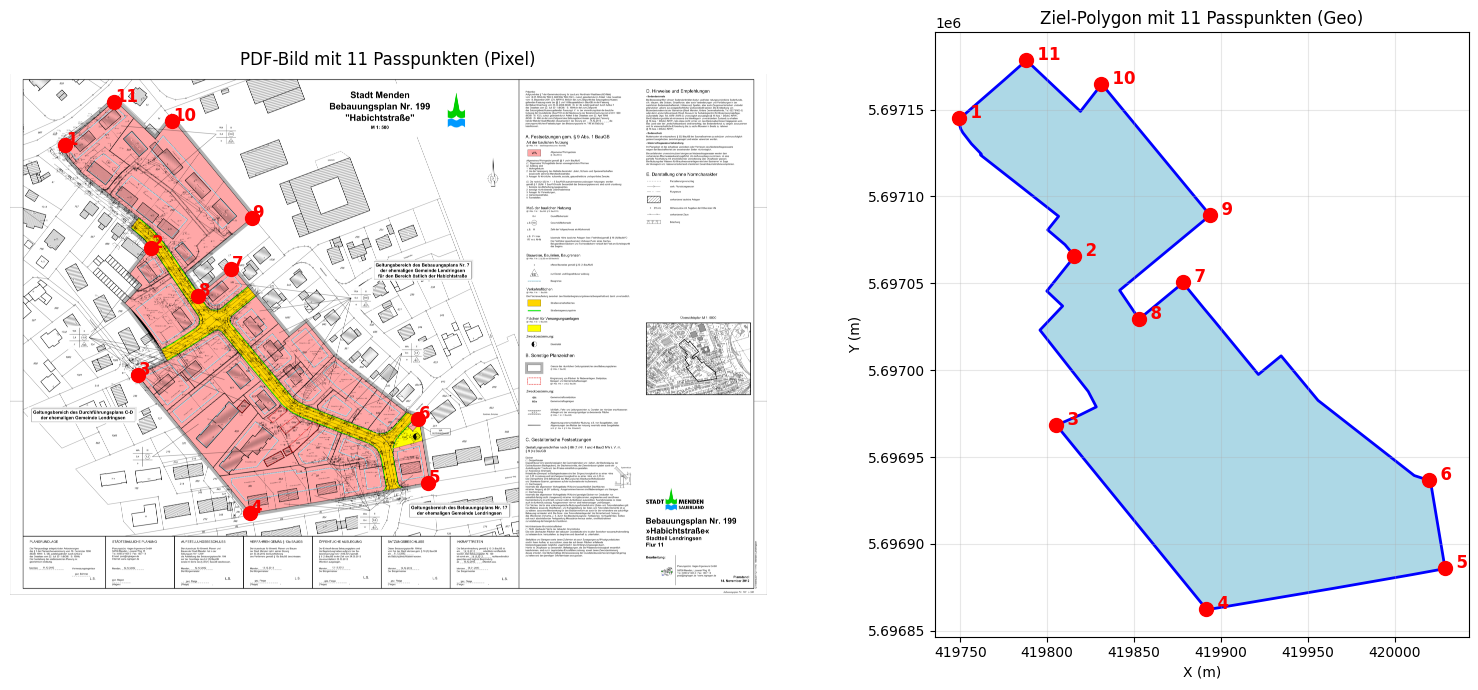

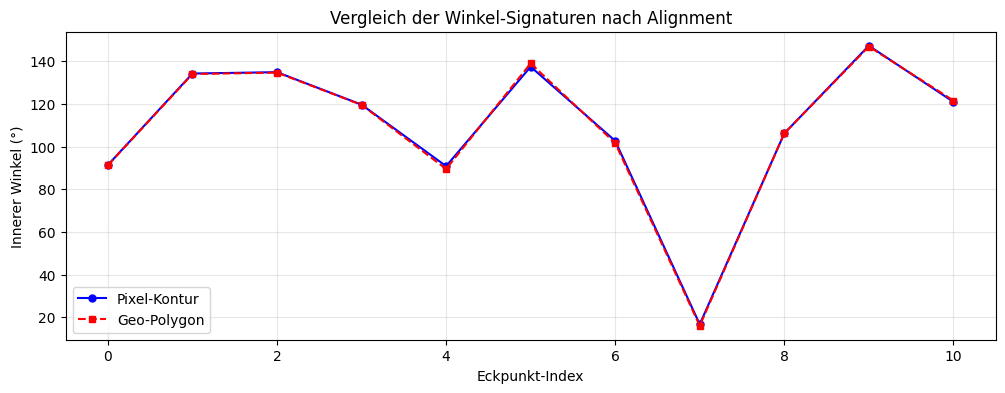


✓ 11 Kontrollpunkte erstellt (Eck-basiertes Matching)


In [13]:
def match_polygon_points(pixel_points, geo_polygon, n_corners=15, debug=True):
    """
    Verbesserte Polygon-Zuordnung mit Eck-basiertem Matching.
    
    Strategie:
    1. BEIDE Konturen auf markante Ecken reduzieren (Douglas-Peucker)
    2. Innere Winkel an jeder Ecke berechnen (charakteristisch für Form)
    3. Winkel-Sequenz als "Fingerprint" - finde beste Ausrichtung (inkl. Spiegelung)
    4. Wenige, gut gematchte Eckpunkte für robuste Transformation
    
    Args:
        pixel_points: Array von (x, y) Pixel-Randpunkten (aus detect_colored_polygon)
        geo_polygon: Shapely Polygon (GeoDataFrame)
        n_corners: Ziel-Anzahl markanter Ecken (Standard: 15)
        debug: Zeigt Debug-Plots
    
    Returns:
        Liste von (pixel_x, pixel_y, geo_x, geo_y) - die Control Points
    """
    import cv2
    from scipy.spatial.distance import cdist
    
    # --- 1. ECKEN extrahieren mit Douglas-Peucker ---
    
    def extract_corners(points, target_n_corners):
        """Reduziert Kontur auf n markante Eckpunkte mittels Douglas-Peucker"""
        # Als OpenCV-Kontur formatieren
        contour = points.reshape(-1, 1, 2).astype(np.float32)
        
        # Epsilon iterativ anpassen bis wir ungefähr target_n_corners haben
        perimeter = cv2.arcLength(contour, closed=True)
        epsilon_min, epsilon_max = 0.001 * perimeter, 0.1 * perimeter
        
        for _ in range(20):
            epsilon = (epsilon_min + epsilon_max) / 2
            approx = cv2.approxPolyDP(contour, epsilon, closed=True)
            n_pts = len(approx)
            
            if abs(n_pts - target_n_corners) <= 2:
                break
            elif n_pts > target_n_corners:
                epsilon_min = epsilon
            else:
                epsilon_max = epsilon
        
        return approx.reshape(-1, 2)
    
    # Pixel-Kontur: Ecken extrahieren
    pixel_corners = extract_corners(pixel_points, n_corners)
    
    # Geo-Polygon: Koordinaten holen und Ecken extrahieren
    geo_coords = np.array(geo_polygon.exterior.coords[:-1])  # Letzten Punkt weglassen (Duplikat)
    geo_corners = extract_corners(geo_coords, n_corners)
    
    print(f"Extrahierte Ecken: {len(pixel_corners)} Pixel, {len(geo_corners)} Geo")
    
    # --- 2. INNERE WINKEL an jeder Ecke berechnen ---
    
    def compute_interior_angles(corners):
        """Berechnet inneren Winkel an jeder Ecke (im Polygon-Kontext)"""
        n = len(corners)
        angles = []
        
        for i in range(n):
            p_prev = corners[(i - 1) % n]
            p_curr = corners[i]
            p_next = corners[(i + 1) % n]
            
            # Vektoren
            v1 = p_prev - p_curr
            v2 = p_next - p_curr
            
            # Winkel zwischen Vektoren
            cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
            cos_angle = np.clip(cos_angle, -1, 1)
            angle = np.arccos(cos_angle)
            angles.append(angle)
        
        return np.array(angles)
    
    pixel_angles = compute_interior_angles(pixel_corners)
    geo_angles = compute_interior_angles(geo_corners)
    
    # --- 3. WINKEL-SEQUENZ MATCHING (Zyklische Alignment) ---
    
    def find_best_match(angles_source, angles_target, allow_flip=True):
        """
        Findet die beste zyklische Ausrichtung und optional Spiegelung 
        zwischen zwei Winkel-Sequenzen.
        
        Returns: (best_offset, flipped, score)
        """
        n_src = len(angles_source)
        n_tgt = len(angles_target)
        
        # Falls unterschiedliche Längen: auf kürzere interpolieren
        if n_src != n_tgt:
            # Resample die längere Sequenz
            n_common = min(n_src, n_tgt)
            src_idx = np.linspace(0, n_src - 1, n_common).astype(int)
            tgt_idx = np.linspace(0, n_tgt - 1, n_common).astype(int)
            angles_source = angles_source[src_idx]
            angles_target = angles_target[tgt_idx]
        
        n = len(angles_source)
        best_score = float('inf')
        best_offset = 0
        best_flip = False
        
        # Teste alle zyklischen Verschiebungen
        for flip in ([False, True] if allow_flip else [False]):
            test_angles = angles_target[::-1] if flip else angles_target
            
            for offset in range(n):
                # Rotiere die Sequenz
                rotated = np.roll(test_angles, offset)
                
                # Score: Summe der Winkel-Differenzen
                diff = np.abs(angles_source - rotated)
                # Wrap-around für Winkel (z.B. 355° vs 5° sollte als 10° Differenz zählen)
                diff = np.minimum(diff, 2 * np.pi - diff)
                score = np.sum(diff)
                
                if score < best_score:
                    best_score = score
                    best_offset = offset
                    best_flip = flip
        
        return best_offset, best_flip, best_score
    
    # Beste Ausrichtung finden
    offset, is_flipped, match_score = find_best_match(pixel_angles, geo_angles)
    
    print(f"Winkel-Matching: Offset={offset}, Gespiegelt={is_flipped}, Score={match_score:.3f}")
    
    # --- 4. KONTROLLPUNKTE ZUORDNEN ---
    
    # Geo-Corners entsprechend ausrichten
    n_geo = len(geo_corners)
    n_pixel = len(pixel_corners)
    n_common = min(n_geo, n_pixel)
    
    # Indizes für Resampling
    geo_idx = np.linspace(0, n_geo - 1, n_common).astype(int)
    pixel_idx = np.linspace(0, n_pixel - 1, n_common).astype(int)
    
    geo_aligned = geo_corners[geo_idx]
    pixel_aligned = pixel_corners[pixel_idx]
    
    # Spiegelung anwenden falls nötig
    if is_flipped:
        geo_aligned = geo_aligned[::-1]
    
    # Offset anwenden
    geo_aligned = np.roll(geo_aligned, offset, axis=0)
    
    # Control Points erstellen
    control_points = []
    for i in range(n_common):
        control_points.append((
            float(pixel_aligned[i, 0]),
            float(pixel_aligned[i, 1]),
            float(geo_aligned[i, 0]),
            float(geo_aligned[i, 1])
        ))
    
    # --- 5. DEBUG VISUALISIERUNG ---
    
    if debug:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Links: PDF-Bild mit Pixel-Ecken
        axes[0].imshow(img_array)
        for i, (px, py, gx, gy) in enumerate(control_points):
            axes[0].plot(px, py, 'ro', markersize=10)
            axes[0].text(px + 10, py, f'{i+1}', color='red', fontsize=12, fontweight='bold')
        axes[0].set_title(f"PDF-Bild mit {len(control_points)} Passpunkten (Pixel)")
        axes[0].axis('off')
        
        # Rechts: Geo-Polygon mit Geo-Ecken
        gdf_temp = gpd.GeoDataFrame([{'geometry': geo_polygon}], crs=target_crs)
        gdf_temp.plot(ax=axes[1], facecolor='lightblue', edgecolor='blue', linewidth=2)
        for i, (px, py, gx, gy) in enumerate(control_points):
            axes[1].plot(gx, gy, 'ro', markersize=10)
            axes[1].text(gx, gy, f'  {i+1}', color='red', fontsize=12, fontweight='bold')
        axes[1].set_title(f"Ziel-Polygon mit {len(control_points)} Passpunkten (Geo)")
        axes[1].set_xlabel("X (m)")
        axes[1].set_ylabel("Y (m)")
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Winkel-Vergleich Plot
        fig, ax = plt.subplots(figsize=(12, 4))
        x = np.arange(n_common)
        
        # Pixel angles (resampled)
        pixel_angles_resampled = compute_interior_angles(pixel_aligned)
        geo_angles_aligned = compute_interior_angles(geo_aligned)
        
        ax.plot(x, np.degrees(pixel_angles_resampled), 'b-o', label='Pixel-Kontur', markersize=5)
        ax.plot(x, np.degrees(geo_angles_aligned), 'r--s', label='Geo-Polygon', markersize=5)
        ax.set_xlabel('Eckpunkt-Index')
        ax.set_ylabel('Innerer Winkel (°)')
        ax.set_title('Vergleich der Winkel-Signaturen nach Alignment')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()
    
    print(f"\n✓ {len(control_points)} Kontrollpunkte erstellt (Eck-basiertes Matching)")
    
    return control_points

# Matching ausführen
if detected_points is not None and len(detected_points) >= 3:
    control_points = match_polygon_points(detected_points, target_geom, n_corners=12, debug=True)
else:
    print("⚠️  Keine Pixel-Kontur gefunden - verwende Bounding Box Fallback")
    h, w = img_array.shape[:2]
    minx, miny, maxx, maxy = target_geom.bounds
    control_points = [
        (0, 0, minx, maxy),
        (w, 0, maxx, maxy),
        (w, h, maxx, miny),
        (0, h, minx, miny),
    ]

### 📊 Qualitätskontrolle der Passpunkte

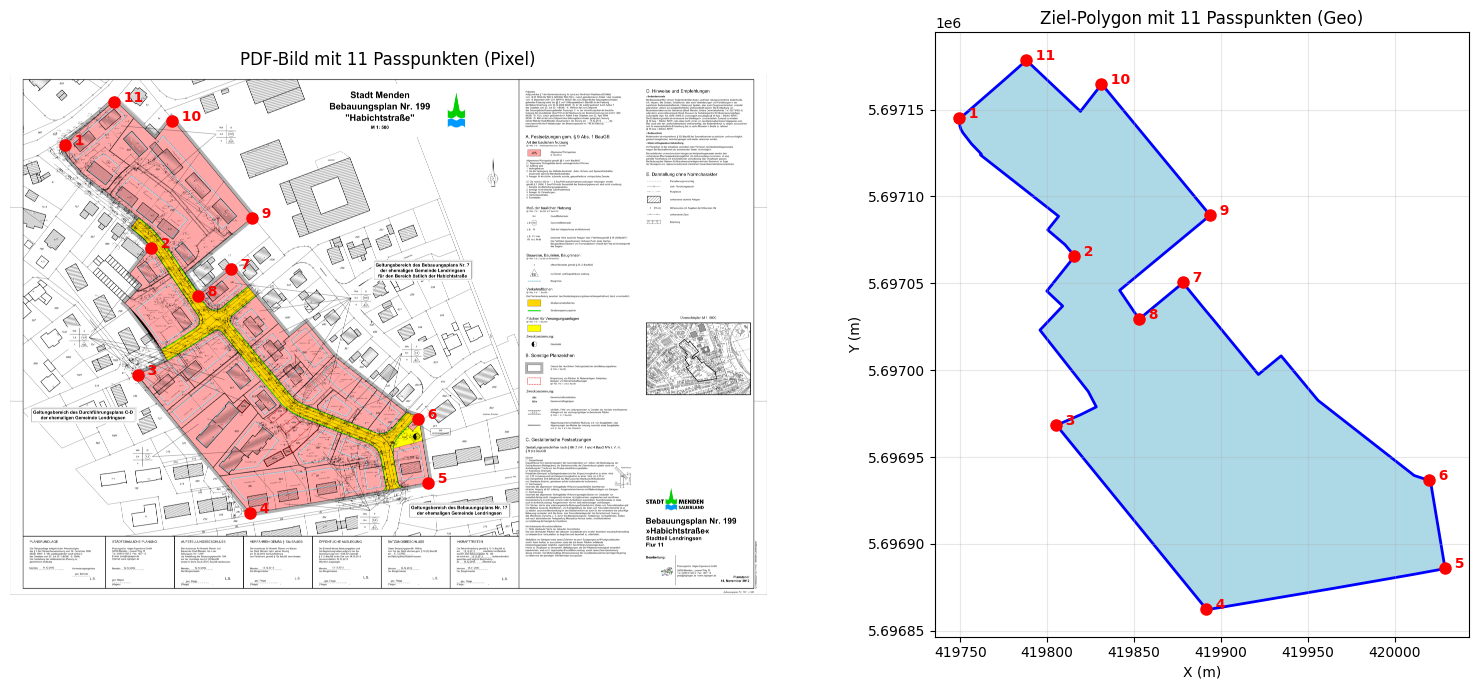


✓ 11 Passpunkte visualisiert
  → Prüfe, ob die Nummerierung auf beiden Seiten übereinstimmt


In [14]:
# Visualisiere die Passpunkt-Zuordnung
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Links: Bild mit Pixel-Punkten
axes[0].imshow(img_array)
for i, cp in enumerate(control_points):
    axes[0].plot(cp[0], cp[1], 'ro', markersize=8)
    axes[0].text(cp[0], cp[1], f'  {i+1}', color='red', fontsize=10, fontweight='bold')
axes[0].set_title(f"PDF-Bild mit {len(control_points)} Passpunkten (Pixel)")
axes[0].axis('off')

# Rechts: Polygon mit Geo-Punkten
gdf_temp = gpd.GeoDataFrame([{'geometry': target_geom}], crs=target_crs)
gdf_temp.plot(ax=axes[1], facecolor='lightblue', edgecolor='blue', linewidth=2)
for i, cp in enumerate(control_points):
    axes[1].plot(cp[2], cp[3], 'ro', markersize=8)
    axes[1].text(cp[2], cp[3], f'  {i+1}', color='red', fontsize=10, fontweight='bold')
axes[1].set_title(f"Ziel-Polygon mit {len(control_points)} Passpunkten (Geo)")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ {len(control_points)} Passpunkte visualisiert")
print("  → Prüfe, ob die Nummerierung auf beiden Seiten übereinstimmt")

## Schritt 4: Affine Transformation berechnen

In [16]:
from rasterio.transform import Affine
from scipy.spatial import procrustes
from sklearn.linear_model import LinearRegression

def compute_affine_transform_from_gcps(control_points):
    """
    Berechnet affine Transformation aus Passpunkten
    
    Args:
        control_points: Liste von (pixel_x, pixel_y, geo_x, geo_y)
    
    Returns:
        rasterio.Affine transform
    """
    # Pixel-Koordinaten (in Rasterio: y von oben nach unten)
    src_points = np.array([[cp[0], cp[1]] for cp in control_points], dtype=float)
    dst_points = np.array([[cp[2], cp[3]] for cp in control_points], dtype=float)
    
    # Affine Transformation: [x_geo, y_geo] = A * [x_pixel, y_pixel] + b
    # In Matrix-Form: [geo_x, geo_y]^T = [[a, b], [d, e]] * [pixel_x, pixel_y]^T + [c, f]^T
    
    # Verwende Least Squares für robuste Schätzung
    # X_geo = a * X_pixel + b * Y_pixel + c
    # Y_geo = d * X_pixel + e * Y_pixel + f
    
    X = np.column_stack([src_points[:, 0], src_points[:, 1], np.ones(len(src_points))])
    
    # Für X-Koordinaten
    coeffs_x = np.linalg.lstsq(X, dst_points[:, 0], rcond=None)[0]
    a, b, c = coeffs_x
    
    # Für Y-Koordinaten
    coeffs_y = np.linalg.lstsq(X, dst_points[:, 1], rcond=None)[0]
    d, e, f = coeffs_y
    
    # Rasterio Affine: (a, b, c, d, e, f)
    # a = x-Skalierung, b = Rotation, c = x-Translation
    # d = Rotation, e = y-Skalierung (negativ!), f = y-Translation
    
    transform = Affine(a, b, c, d, e, f)
    
    # Residuals berechnen
    predicted = []
    for cp in control_points:
        x_pred = a * cp[0] + b * cp[1] + c
        y_pred = d * cp[0] + e * cp[1] + f
        predicted.append([x_pred, y_pred])
    
    predicted = np.array(predicted)
    residuals = np.sqrt(np.sum((dst_points - predicted)**2, axis=1))
    
    print(f"✓ Affine Transformation berechnet")
    print(f"  Transformation Matrix:")
    print(f"    a={a:.6f}, b={b:.6f}, c={c:.2f}")
    print(f"    d={d:.6f}, e={e:.6f}, f={f:.2f}")
    print(f"  Residuals (m): {residuals}")
    print(f"  Mittlerer Fehler: {np.mean(residuals):.2f}m")
    print(f"  Max. Fehler: {np.max(residuals):.2f}m")
    
    return transform

# Transformation berechnen
height, width = img_array.shape[:2]
transform = compute_affine_transform_from_gcps(control_points)
print(f"\nRasterio Affine Transform:\n{transform}")
print(f"Bildgröße: {width} x {height} Pixel")

✓ Affine Transformation berechnet
  Transformation Matrix:
    a=0.042355, b=0.000035, c=419707.25
    d=0.000324, e=-0.042540, f=5697199.58
  Residuals (m): [0.52629343 0.43717167 0.82186877 0.20229618 0.91107177 1.37744908
 0.79677761 0.7087874  0.64796296 0.89172986 0.44893211]
  Mittlerer Fehler: 0.71m
  Max. Fehler: 1.38m

Rasterio Affine Transform:
| 0.04, 0.00, 419707.25|
| 0.00,-0.04, 5697199.58|
| 0.00, 0.00, 1.00|
Bildgröße: 13701 x 9449 Pixel


## Schritt 5: Als GeoTIFF speichern

In [18]:
def save_geotiff(img_array, transform, crs, output_path):
    """
    Speichert georeferenziertes Bild als GeoTIFF
    
    Args:
        img_array: Bild als numpy array (H, W, C)
        transform: rasterio.Affine transform
        crs: CRS (z.B. von GeoDataFrame)
        output_path: Ausgabe-Pfad
    """
    height, width = img_array.shape[:2]
    
    # Kanäle bestimmen
    if len(img_array.shape) == 2:
        count = 1
        img_data = img_array
    else:
        count = img_array.shape[2]
        img_data = img_array
    
    # GeoTIFF schreiben
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=count,
        dtype=img_array.dtype,
        crs=crs,
        transform=transform,
        compress='lzw'
    ) as dst:
        if count == 1:
            dst.write(img_data, 1)
        else:
            # Channels: (H, W, C) → (C, H, W)
            for i in range(count):
                dst.write(img_data[:, :, i], i + 1)
    
    print(f"✓ GeoTIFF gespeichert: {output_path}")
    print(f"  Größe: {width} x {height} x {count}")
    print(f"  CRS: {crs}")
    print(f"  Transform: {transform}")

# GeoTIFF speichern
output_tif = r"C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_georef.tif"
save_geotiff(img_array, transform, target_crs, output_tif)

✓ GeoTIFF gespeichert: C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_georef.tif
  Größe: 13701 x 9449 x 3
  CRS: EPSG:25832
  Transform: | 0.04, 0.00, 419707.25|
| 0.00,-0.04, 5697199.58|
| 0.00, 0.00, 1.00|


## Schritt 6: Ergebnis verifizieren

In [19]:
# GeoTIFF öffnen und prüfen
with rasterio.open(output_tif) as src:
    print(f"GeoTIFF Metadaten:")
    print(f"  CRS: {src.crs}")
    print(f"  Transform: {src.transform}")
    print(f"  Bounds: {src.bounds}")
    print(f"  Größe: {src.width} x {src.height}")
    print(f"  Anzahl Bänder: {src.count}")
    
    # Bounds vergleichen
    tif_bounds = src.bounds
    poly_bounds = target_geom.bounds
    
    print(f"\nVergleich Bounds:")
    print(f"  GeoTIFF: ({tif_bounds.left:.2f}, {tif_bounds.bottom:.2f}, {tif_bounds.right:.2f}, {tif_bounds.top:.2f})")
    print(f"  Polygon:  ({poly_bounds[0]:.2f}, {poly_bounds[1]:.2f}, {poly_bounds[2]:.2f}, {poly_bounds[3]:.2f})")
    
    # Erstes Band als Vorschau lesen
    band1 = src.read(1)

GeoTIFF Metadaten:
  CRS: EPSG:25832
  Transform: | 0.04, 0.00, 419707.25|
| 0.00,-0.04, 5697199.58|
| 0.00, 0.00, 1.00|
  Bounds: BoundingBox(left=419707.25109278096, bottom=5696797.620394982, right=420287.89109849354, top=5697204.024711552)
  Größe: 13701 x 9449
  Anzahl Bänder: 3

Vergleich Bounds:
  GeoTIFF: (419707.25, 5696797.62, 420287.89, 5697204.02)
  Polygon:  (419749.40, 5696862.39, 420028.75, 5697178.69)


## Schritt 7: Auf Polygon zuschneiden (Clip)

In [20]:
from rasterio.mask import mask
from shapely.geometry import mapping

def clip_geotiff_to_polygon(input_tif, polygon_geom, output_tif):
    """
    Schneidet ein georeferenziertes GeoTIFF auf ein Polygon zu
    
    Args:
        input_tif: Pfad zum Eingabe-GeoTIFF
        polygon_geom: Shapely Polygon (aus GeoDataFrame)
        output_tif: Pfad zum Ausgabe-GeoTIFF (zugeschnitten)
    
    Returns:
        Zugeschnittenes Array, Transform
    """
    with rasterio.open(input_tif) as src:
        # Polygon in GeoJSON-Format für rasterio
        geom = [mapping(polygon_geom)]
        
        # Zuschneiden
        out_image, out_transform = mask(src, geom, crop=True, all_touched=False)
        out_meta = src.meta.copy()
        
        # Metadaten aktualisieren
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "compress": "lzw"
        })
        
        # Zugeschnittenes GeoTIFF speichern
        with rasterio.open(output_tif, "w", **out_meta) as dest:
            dest.write(out_image)
        
        print(f"✓ GeoTIFF zugeschnitten: {output_tif}")
        print(f"  Original: {src.width} x {src.height}")
        print(f"  Zugeschnitten: {out_meta['width']} x {out_meta['height']}")
        print(f"  Datenreduktion: {(1 - (out_meta['width'] * out_meta['height']) / (src.width * src.height)) * 100:.1f}%")
        
        return out_image, out_transform

# Auf Polygon zuschneiden
output_tif_clipped = r"C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_georef_clipped.tif"
clipped_img, clipped_transform = clip_geotiff_to_polygon(output_tif, target_geom, output_tif_clipped)

✓ GeoTIFF zugeschnitten: C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_georef_clipped.tif
  Original: 13701 x 9449
  Zugeschnitten: 6592 x 7455
  Datenreduktion: 62.0%


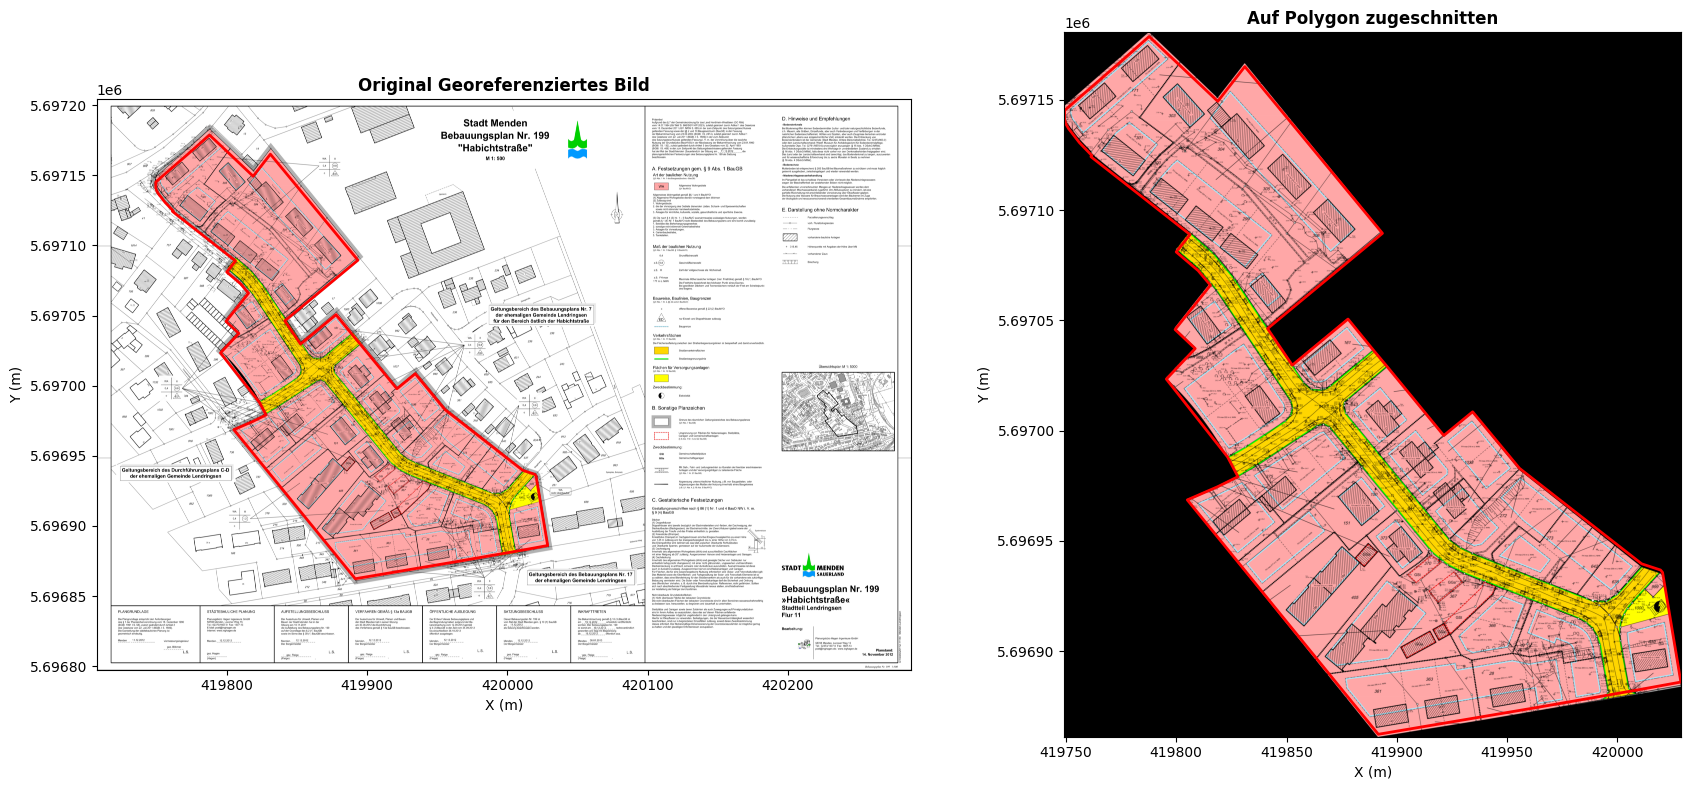


✓ Fertig! Das Bild wurde auf das Polygon zugeschnitten.


In [25]:
import rasterio.plot as rioplot

# Zugeschnittenes Bild visualisieren
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Links: Original GeoTIFF
with rasterio.open(output_tif) as src:
    rioplot.show(src, ax=axes[0], title="Original Georeferenziertes Bild")
    bplan.iloc[40:41].plot(ax=axes[0], facecolor='none', edgecolor='red', linewidth=2)
    axes[0].set_xlabel("X (m)")
    axes[0].set_ylabel("Y (m)")

# Rechts: Zugeschnittenes GeoTIFF
with rasterio.open(output_tif_clipped) as src:
    rioplot.show(src, ax=axes[1], title="Auf Polygon zugeschnitten")
    bplan.iloc[40:41].plot(ax=axes[1], facecolor='none', edgecolor='red', linewidth=2)
    axes[1].set_xlabel("X (m)")
    axes[1].set_ylabel("Y (m)")

plt.tight_layout()
plt.show()

print("\n✓ Fertig! Das Bild wurde auf das Polygon zugeschnitten.")

### Optional: Maske auf Polygon-Form anwenden

Falls du NUR die Pixel innerhalb des Polygons behalten möchtest (Rest transparent/NoData):

In [39]:
def clip_with_mask(input_tif, polygon_geom, output_tif, nodata=0):
    """
    Schneidet GeoTIFF zu und wendet Polygon-Maske an
    Pixel außerhalb des Polygons werden auf NoData gesetzt
    
    Args:
        input_tif: Pfad zum Eingabe-GeoTIFF
        polygon_geom: Shapely Polygon
        output_tif: Pfad zum Ausgabe-GeoTIFF
        nodata: NoData-Wert (Standard: 0 für Schwarz, oder 255 für Weiß)
    """
    with rasterio.open(input_tif) as src:
        # Polygon als GeoJSON
        geom = [mapping(polygon_geom)]
        
        # Mit Maske zuschneiden (filled=False behält NoData)
        out_image, out_transform = mask(src, geom, crop=True, nodata=nodata)
        out_meta = src.meta.copy()
        
        # Metadaten aktualisieren
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": nodata,
            "compress": "lzw"
        })
        
        # Speichern
        with rasterio.open(output_tif, "w", **out_meta) as dest:
            dest.write(out_image)
        
        print(f"✓ Mit Polygon-Maske zugeschnitten: {output_tif}")
        print(f"  NoData-Wert: {nodata}")
        
        return out_image, out_transform

# Beispiel: Mit Maske (optional ausführen)
# output_tif_masked = r"C:\Users\arber\Desktop\scouting-python\Bplan_georeferenzer\bplan_georef_masked.tif"
# masked_img, masked_transform = clip_with_mask(output_tif, target_geom, output_tif_masked, nodata=255)
print("💡 Um Maske anzuwenden, kommentiere die letzten 2 Zeilen oben aus.")

💡 Um Maske anzuwenden, kommentiere die letzten 2 Zeilen oben aus.


## ✅ Zusammenfassung der erstellten Dateien

In [ ]:
import os

print("📁 Erstellte Dateien:")
print("-" * 60)

files_to_check = [
    ("Temporäres PNG", png_path),
    ("Georeferenziertes GeoTIFF (voll)", output_tif),
    ("Zugeschnittenes GeoTIFF", output_tif_clipped),
]

for name, path in files_to_check:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {name}:")
        print(f"  {path}")
        print(f"  Größe: {size_mb:.2f} MB")
    else:
        print(f"✗ {name}: Nicht gefunden")
    print()

print("🎯 Hauptergebnis: bplan_georef_clipped.tif")
print("   → Georeferenziert und auf Polygon zugeschnitten")